# Compare conditions

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA

import flexible_pca
import importlib
importlib.reload(flexible_pca)
from flexible_pca import FlexiblePCA, TrialSpec, create_standard_specs

import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib widget

In [63]:
analyzer = MultiSessionPCA({
    # 'epok': [-100, 300],
    # 'bin_size': 1,
    # 'smooth_ker_size': 25,
    # 'alignment_point': 'go_cue',
    # 'ssd_number': 2,
    # 'normalize': False,
    # 'delta': False,
    # 'subtract_average_PSTH': False,
    'excluded_sessions': [],
    'min_cells_per_session': 10,
    'min_trials_per_condition': 20,
    'monkey': 'fiona',
    'n_pca_components': 5,
    'n_workers': 19,
    'normalize': False,
    'required_directions': [0],
    'required_trial_types': ['GO', 'STOP', 'CONT'],
})

analyzer.load_data('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl')
analyzer.cell_df = analyzer.cell_df[analyzer.cell_df['cell_type'] == 'msn']

analyzer.validate_all_sessions()
print(f"✓ Valid sessions: {len(analyzer.valid_sessions)}")

cell_df = analyzer.cell_df[analyzer.cell_df['trial_session'].isin(analyzer.valid_sessions)]
cell_df = cell_df[~cell_df['cell_ID'].isin([2134])]
cell_df = cell_df[~cell_df['cell_ID'].isin([1352])]

Loading data from: ../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl
✓ Database loaded: 1,939,269 cell-trial combinations
  Total sessions: 61
  Total unique cells: 3096
✓ Session statistics computed for 50 sessions
  Excluded sessions: 0
  Candidate sessions: 50
Validating sessions...
--------------------------------------------------------------------------------
✓ fi211102a: Valid (70 cells)
✓ fi211110a: Valid (57 cells)
✓ fi211115a: Valid (56 cells)
✓ fi210909a: Valid (52 cells)
✓ fi210907a: Valid (52 cells)
✓ fi211118a: Valid (46 cells)
✓ fi211104a: Valid (45 cells)
✓ fi211025a: Valid (44 cells)
✓ fi210817a: Valid (43 cells)
✓ fi210811a: Valid (43 cells)
✓ fi211111a: Valid (37 cells)
✓ fi210725a: Valid (36 cells)
✓ fi210818a: Valid (34 cells)
✓ fi210728a: Valid (34 cells)
✓ fi210908a: Valid (34 cells)
✓ fi211109a: Valid (32 cells)
✓ fi211108a: Valid (32 cells)
✓ fi210823a: Valid (31 cells)
✓ fi210721a: Valid (31 cells)
✓ fi210727a: Valid (31 cells

In [64]:
# Load data
# cell_df = pd.read_pickle('../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl')
# cell_df = pd.read_pickle('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl')

# Filter data
# excluded_sessions = ['fi210628', 'fi210629', 'fi210704']
# cell_df = cell_df[~cell_df['trial_session'].isin(excluded_sessions)]
# cell_df = cell_df[cell_df['trial_failed'] == False]

# Filter to sessions with enough cells
min_cells = 15
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique()
valid_sessions = session_cell_counts[session_cell_counts >= min_cells].index.tolist()
cell_df = cell_df[cell_df['trial_session'].isin(valid_sessions)]

print(f"Data loaded: {len(cell_df):,} trials, {cell_df['cell_ID'].nunique()} cells")

Data loaded: 723,793 trials, 1281 cells


# PCA analysis

In [65]:
# Create FlexiblePCA instance
SMOOTH_KER_SIZE = 7
CONTRA_DIR = 0

fpca = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=SMOOTH_KER_SIZE,
    n_components=5,
    pca_function=TruncatedSVD,
    n_jobs=-1,
    z_score=False
)

# Create standard specs: all 6 conditions, align to go_cue, epoch [-50, 500]
ALIGNMENT_POINT = 'stop_cue'
EPOCH = [0, 400]
specs = [
    TrialSpec('GO', direction=CONTRA_DIR, epoch=EPOCH, alignment=ALIGNMENT_POINT, success_only=True, failed_only=False, is_slow_go=None),
    # TrialSpec('CONT', direction=CONTRA_DIR, epoch=EPOCH, alignment=ALIGNMENT_POINT, success_only=True, failed_only=False, is_slow_go=None),
    TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=ALIGNMENT_POINT, 
        success_only=True, 
        failed_only=False,
        # label='ERROR_STOP_R'
    ),
]

# Fit PCA on all conditions
fpca.fit(specs)


FITTING PCA

Conditions for fitting:
  GO_R: epoch [0, 400] ms, aligned to stop_cue
  STOP_R: epoch [0, 400] ms, aligned to stop_cue

Extracting PSTHs for 1281 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1281/1281 [00:03<00:00, 385.72it/s]



✓ PSTH extraction complete
  Total neurons processed: 1281
  Neurons with all conditions: 1281
  Neurons excluded (missing conditions): 0
  Data matrix shape: (1281, 800)

Trial counts per condition (neurons with all conditions):
  GO_R           : mean=150.2, min=8, max=435
  STOP_R         : mean=37.5, min=1, max=105

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 6.76 ± 8.01 spikes/sec
  Normalized data: mean=0.000000, std=3.715

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 25.37%
    PC2: 20.75%
    PC3: 8.13%
    PC4: 5.51%
    PC5: 3.43%
  Total variance explained: 63.20%



In [66]:
# Get trajectories and time axes
trajectories = fpca.get_fit_trajectories()
time_axes = {label: fpca.get_time_axis(spec) for spec in specs for label in [spec.get_label_for_direction(d) for d in spec.get_directions()]}

## PCA explained var


Explained variance by component:
  PC1: 25.37%
  PC2: 20.75%
  PC3: 8.13%
  PC4: 5.51%
  PC5: 3.43%

Total variance explained by 5 components: 63.20%


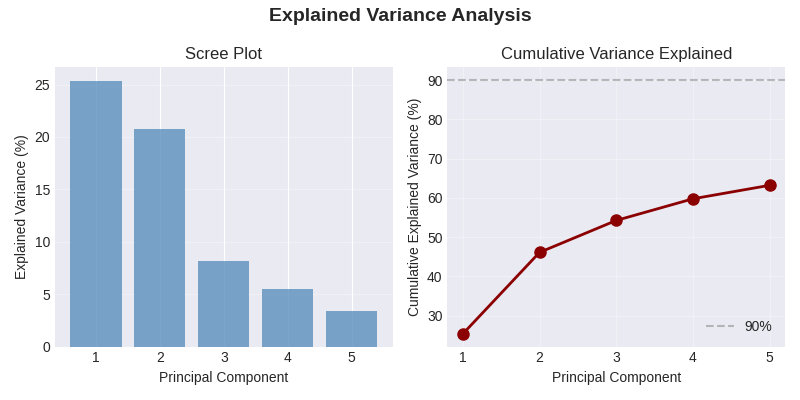

In [67]:
# Plot explained variance
fpca.plot_explained_variance(
    title='Explained Variance Analysis', 
    figsize=(8,4)
)
plt.show()

# Project SPECs


PROJECTING DATA

Conditions for projection:
  FAST_GO_R: epoch [-300, 600] ms, aligned to stop_cue
  GO_R: epoch [-300, 600] ms, aligned to stop_cue
  FAST_CONT_R: epoch [-300, 600] ms, aligned to stop_cue
  STOP_R: epoch [-300, 600] ms, aligned to stop_cue
  ERROR_STOP_R: epoch [-300, 600] ms, aligned to stop_cue

Extracting PSTHs for 1281 neurons...


Processing FAST_GO_R: 100%|██████████| 1281/1281 [00:03<00:00, 398.11it/s]


(1281,), (1281, 900)
  FAST_GO_R: 1281/1281 neurons have data
 :X_condition mean 6.399290761915779, std 8.55841807519297
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)


Processing GO_R: 100%|██████████| 1281/1281 [00:03<00:00, 384.10it/s]


(1281,), (1281, 900)
  GO_R: 1281/1281 neurons have data
 :X_condition mean 6.405976192594771, std 8.063692501342457
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)


...

(1281,), (1281, 900)
  FAST_CONT_R: 1259/1281 neurons have data
 :X_condition mean 6.3094683124784225, std 9.754973778374634
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)


Processing STOP_R: 100%|██████████| 1281/1281 [00:03<00:00, 396.75it/s]


(1281,), (1281, 900)
  STOP_R: 1281/1281 neurons have data
 :X_condition mean 6.5527662037563115, std 8.844131834318878
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)


Processing ERROR_STOP_R: 100%|██████████| 1281/1281 [00:03<00:00, 396.93it/s]


(1281,), (1281, 900)
  ERROR_STOP_R: 1281/1281 neurons have data
 :X_condition mean 6.697104365944763, std 9.327400451748497
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)

✓ Projection complete


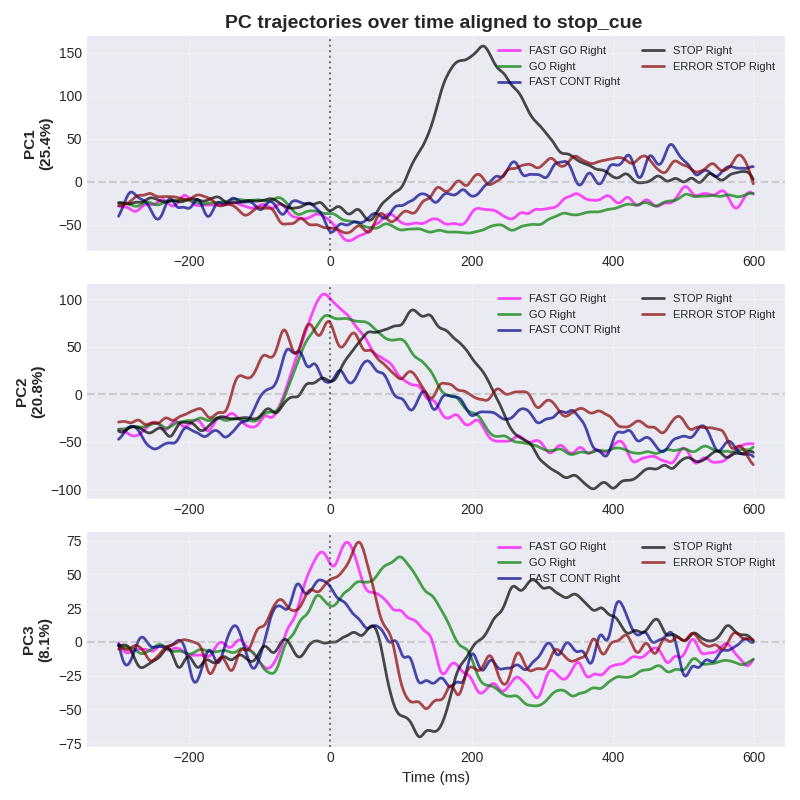

In [68]:
epochs_dict = {
    'go_cue': [-100, 600],
    'stop_cue': [-300, 600],
    'first_relevant_saccade': [-300, 300],
}

proj_alignment_pt= 'stop_cue'
is_slow = False
EPOCH = epochs_dict[proj_alignment_pt]
proj_specs = [
    TrialSpec(
        'GO', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=True, failed_only=False, is_slow_go=is_slow, label='FAST_GO_R'
    ),
    TrialSpec(
        'GO', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=True, failed_only=None, is_slow_go=None
    ),
    TrialSpec(
        'CONT', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt,
        success_only=True, failed_only=False, is_slow_go=is_slow, label='FAST_CONT_R'
    ),
]
proj_specs.append(TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=True, failed_only=False, is_slow_go=None,
))
proj_specs.append(TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=False, failed_only=True, is_slow_go=None,
        label='ERROR_STOP_R'
))
projections = fpca.project(proj_specs)
# projections.update(trajectories)
time_axes.update({label: fpca.get_time_axis(spec) for spec in proj_specs for label in [spec.get_label_for_direction(d) for d in spec.get_directions()]})

fpca.plot_pc_timeseries(
    # trajectories,
    projections,
    time_axes,
    n_pcs=3,
    title=f'PC trajectories over time aligned to {proj_alignment_pt} {"(slow go & cont)" if is_slow else ""}',
    figsize=(8, 8)
)
plt.show()

In [69]:
stop, err_stop = projections['STOP_R'][1][300:], projections['ERROR_STOP_R'][1][300:]
print(f"STOP shape: {stop.shape}, ERROR_STOP shape: {err_stop.shape}")
# Find intersection point where trajectories cross
# Calculate Euclidean distance between trajectories at each timepoint
distances = np.abs(stop - err_stop)
print(f"Distances shape: {distances.shape}")

# Find the timepoint with minimum distance (closest approach)
intersection_idx = np.argmin(distances)
intersection_time = time_axes['STOP_R'][intersection_idx + 300]

stop_max_idx = np.argmax(stop)
stop_max_time = time_axes['STOP_R'][stop_max_idx + 300]

print(f"Closest approach at time: {intersection_time:.1f} ms")
print(f"Minimum distance: {distances[intersection_idx]:.4f}")
print(f"Max STOP time: {stop_max_time:.1f} ms")

STOP shape: (600,), ERROR_STOP shape: (600,)
Distances shape: (600,)
Closest approach at time: 588.0 ms
Minimum distance: 0.1392
Max STOP time: 117.0 ms


In [70]:
stop, go = projections['STOP_R'][0], projections['GO_R'][0]
base_stop, base_go = stop[:350], go[:350]
std = np.std(base_stop - base_go)
print(f"Baseline STD: {std:.2f}")

dists = np.abs(stop - go[0])
print(f"Distances shape: {dists.shape}")
significant_timepoints = np.where(dists > (2 * std))[0][0]
significant_times = time_axes['STOP_R'][significant_timepoints]
print(f"Significant divergence timepoints: {significant_timepoints}")
significant_times

Baseline STD: 5.05
Distances shape: (900,)
Significant divergence timepoints: 322


np.float64(22.0)

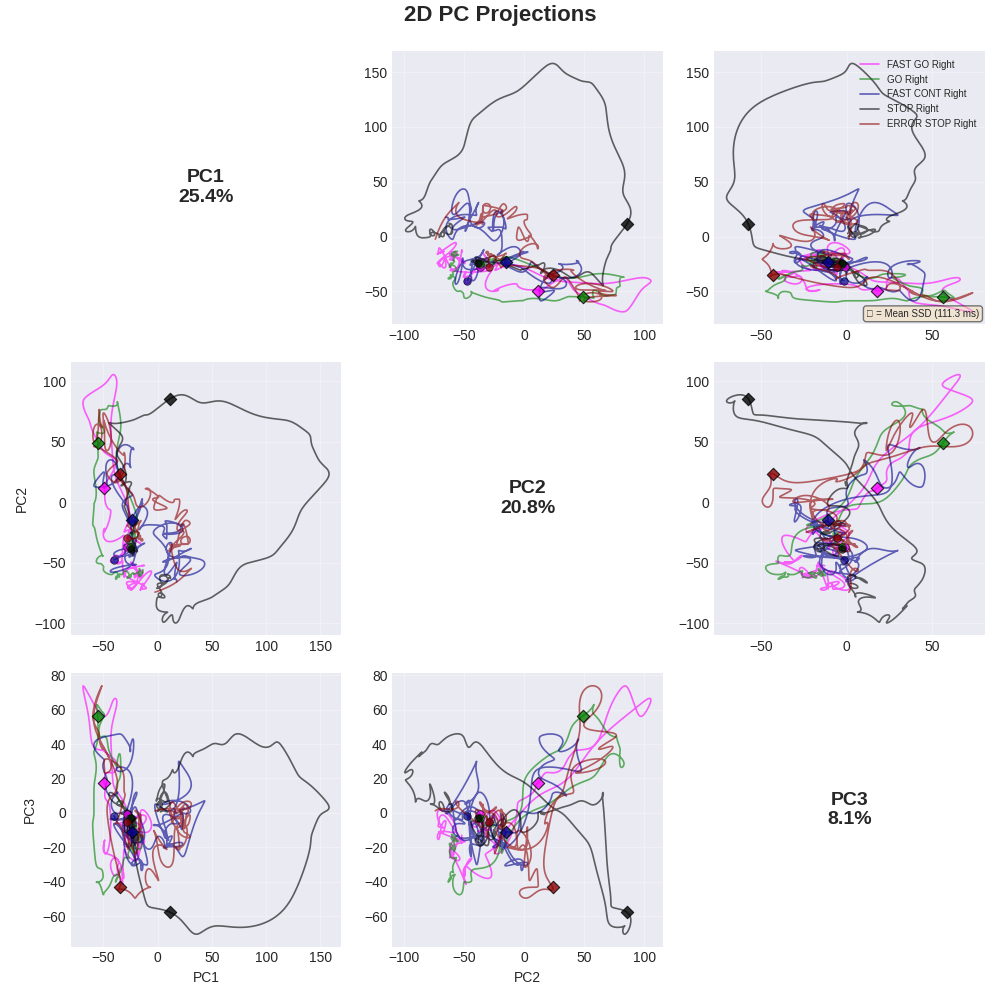

In [71]:
# Plot 2D projections matrix (mean SSD marker added automatically)
fpca.plot_2d_projections(
    # trajectories,
    projections,
    time_axes,
    n_pcs=3,
    title='2D PC Projections',
    figsize=(10, 10)
)
plt.show()

Neurons above mean + std: 120 of 1281 (9.4%)


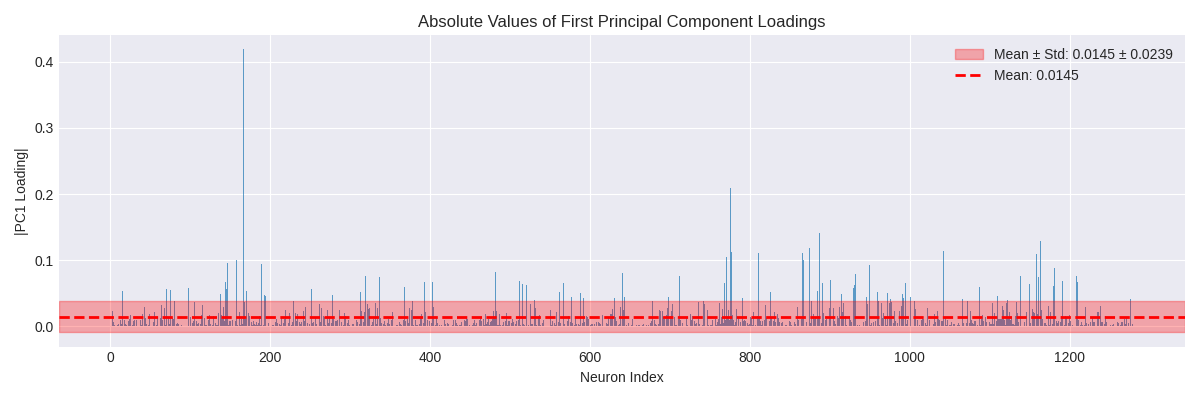

In [72]:
# Plot absolute values of first PC loadings with mean ± std shaded region
pc1_loadings = np.abs(fpca.pca_model.components_[0])

mean_loading = pc1_loadings.mean()
std_loading = pc1_loadings.std()

n_above_threshold = np.sum(pc1_loadings > (mean_loading + std_loading))
print(f"Neurons above mean + std: {n_above_threshold} of {len(pc1_loadings)} ({100*n_above_threshold/len(pc1_loadings):.1f}%)")
plt.figure(figsize=(12, 4))
plt.bar(range(len(pc1_loadings)), pc1_loadings, alpha=0.7)

# Add shaded error region for mean ± std
plt.axhspan(mean_loading - std_loading, mean_loading + std_loading, 
            alpha=0.3, color='red', label=f'Mean ± Std: {mean_loading:.4f} ± {std_loading:.4f}')
plt.axhline(mean_loading, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_loading:.4f}')

plt.xlabel('Neuron Index')
plt.ylabel('|PC1 Loading|')
plt.title('Absolute Values of First Principal Component Loadings')
plt.legend()
plt.tight_layout()
plt.show()